In [22]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
df = pd.read_csv("Social_Network_Ads.csv")

In [37]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [38]:
df=df.iloc[:,2:]

In [39]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [41]:
df.sample(5)

,Age,EstimatedSalary,Purchased
363,42,79000,0
297,43,112000,1
273,39,106000,1
188,35,72000,0
340,53,104000,1


## Train test split

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased'
                                                            , axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                  )

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [43]:
X_train

,Age,EstimatedSalary
333,40,65000
160,32,100000
71,24,27000
267,37,74000
202,39,134000
...,...,...
266,40,75000
166,22,55000
145,24,89000
316,54,104000


In [44]:
y_train


333    0
160    1
71     0
267    0
202    1
      ..
266    0
166    0
145    0
316    1
240    1
Name: Purchased, Length: 280, dtype: int64

# StandardScaler

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
scaler.mean_

array([3.80535714e+01, 7.06857143e+04])

In [18]:
#X_train

In [48]:
#X_train_scaled

In [49]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [50]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.2,70946.4
std,10.3,34824.6
min,18.0,15000.0
25%,29.0,43750.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [52]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.0,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scaling

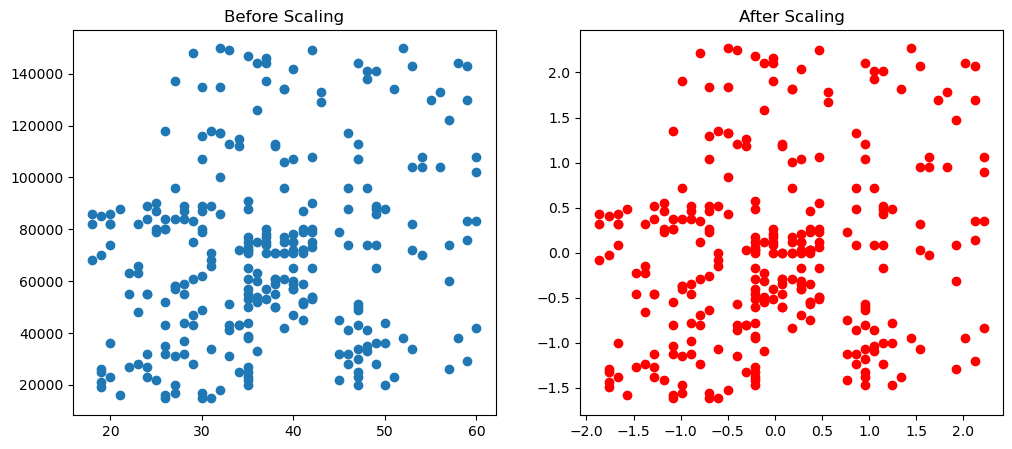

In [53]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

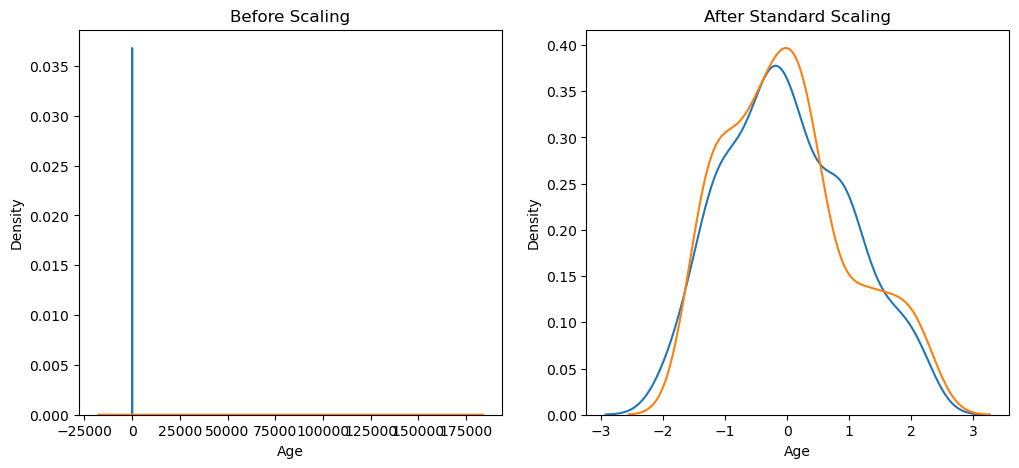

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Comparison of Distributions

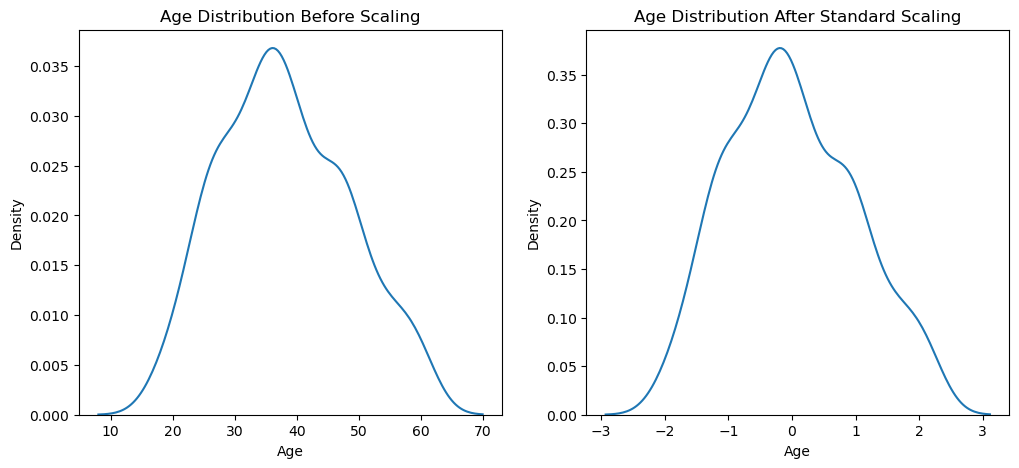

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

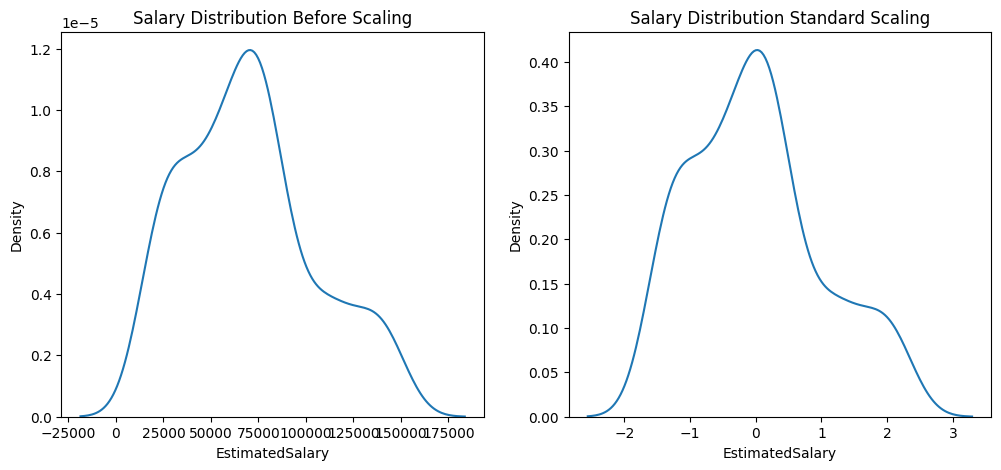

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why scaling is important?

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [21]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [22]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.9333333333333333
Scaled 0.9333333333333333


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [27]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [28]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [29]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


In [25]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Effect of Outlier

In [26]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

In [27]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


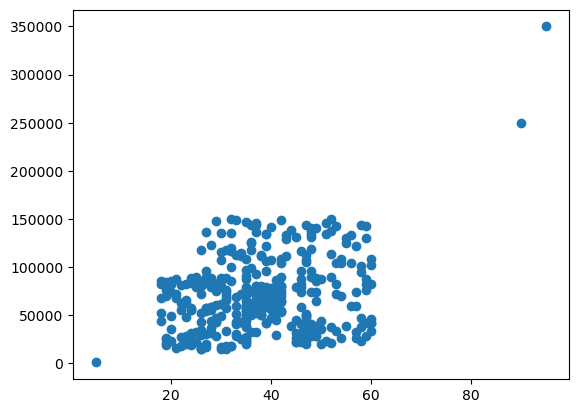

In [28]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

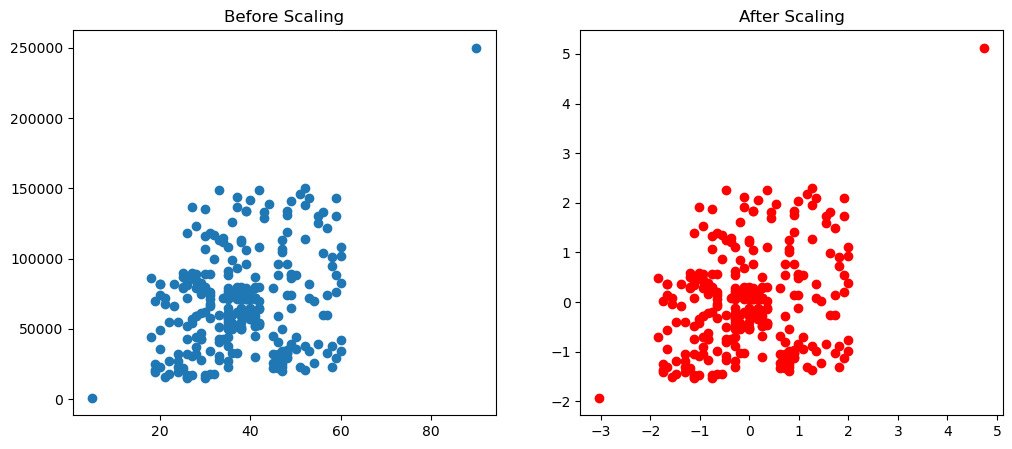

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

In [33]:

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
data = load_breast_cancer()
X = data.data

y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25
)
model1 = LogisticRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy_before_scaling = accuracy_score(y_test, y_pred1)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = LogisticRegression()

model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)

accuracy_after_scaling = accuracy_score(y_test, y_pred2)

print("Accuracy before scaling :", accuracy_before_scaling)
print("Accuracy after scaling  :", accuracy_after_scaling)


Accuracy before scaling : 0.9440559440559441
Accuracy after scaling  : 0.9790209790209791


C:\Users\admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
dataset = pd.read_csv("Social_Network_Ads.csv")
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

model1 = LogisticRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy_before = accuracy_score(y_test, y_pred1)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = LogisticRegression()

model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)

accuracy_after = accuracy_score(y_test, y_pred2)

print("Accuracy after scaling:", accuracy_after)

print("Accuracy before scaling:", accuracy_before)


Accuracy after scaling: 0.89
Accuracy before scaling: 0.89


In [34]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
dataset = pd.read_csv("Social_Network_Ads.csv")
X = dataset.iloc[:, [2,3]].values
y = dataset.iloc[:, 4].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25
)
model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)
accuracy_after = accuracy_score(y_test, y_pred2)
print("Accuracy before scaling :", accuracy_before)
print("Accuracy after scaling  :", accuracy_after)

Accuracy before scaling : 0.78
Accuracy after scaling  : 0.92


In [32]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

dataset = pd.read_csv("Social_Network_Ads.csv")


X = dataset.iloc[:, [2,3]].values   # Age and EstimatedSalary
y = dataset.iloc[:, 4].values       # Purchased

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

model1 = SVC(kernel='rbf')
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model2 = SVC(kernel='rbf')
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)
accuracy_after = accuracy_score(y_test, y_pred2)
print("Accuracy before scaling :", accuracy_before)
print("Accuracy after scaling  :", accuracy_after)


Accuracy before scaling : 0.8
Accuracy after scaling  : 0.93


In [33]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
dataset = pd.read_csv("Social_Network_Ads.csv")

X = dataset.iloc[:, [2,3]].values   # Age and EstimatedSalary
y = dataset.iloc[:, 4].values       # Purchased
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)
model1 = SVC(kernel='rbf')
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred1)
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)
model2 = SVC(kernel='rbf')
model2.fit(X_train_norm, y_train)
y_pred2 = model2.predict(X_test_norm)
accuracy_after = accuracy_score(y_test, y_pred2)
print("Accuracy before normalization :", accuracy_before)
print("Accuracy after normalization  :", accuracy_after)


Accuracy before normalization : 0.8
Accuracy after normalization  : 0.93


In [38]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

dataset = pd.read_csv("Social_Network_Ads.csv")


X = dataset.iloc[:, [2,3]].values   # Age and EstimatedSalary
y = dataset.iloc[:, 4].values       # Purchased


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


model1 = LogisticRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy_before = accuracy_score(y_test, y_pred1)


scaler = MinMaxScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)



model2 = LogisticRegression()

model2.fit(X_train_norm, y_train)

y_pred2 = model2.predict(X_test_norm)

accuracy_after = accuracy_score(y_test, y_pred2)



print("Accuracy before normalization :", accuracy_before)
print("Accuracy after normalization  :", accuracy_after)



Accuracy before normalization : 0.89
Accuracy after normalization  : 0.89


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score


dataset = pd.read_csv("Social_Network_Ads.csv")

X = dataset.iloc[:, [2,3]].values   # Age and EstimatedSalary
y = dataset.iloc[:, 4].values       # Purchased


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


knn1 = KNeighborsClassifier(n_neighbors=5)

knn1.fit(X_train, y_train)

y_pred1 = knn1.predict(X_test)

accuracy_before = accuracy_score(y_test, y_pred1)


scaler = MinMaxScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)



knn2 = KNeighborsClassifier(n_neighbors=5)

knn2.fit(X_train_norm, y_train)

y_pred2 = knn2.predict(X_test_norm)

accuracy_after = accuracy_score(y_test, y_pred2)





print("Accuracy before normalization :", accuracy_before)
print("Accuracy after normalization  :", accuracy_after)



Accuracy before normalization : 0.83
Accuracy after normalization  : 0.93
